In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

In [9]:
df = pd.read_csv('../data/engineered/dataset_mood_smartphone_ts.csv')
df = df.sort_values(["id", "date"])
df.head()

,id,date,activity,mood,screen,emotion,count_call_and_sms,total_app_use,social_ratio,productive_ratio,passive_entertainment_ratio,adventure_ratio,miscellaneous_ratio
0,AS14.01,2014-02-17,0.080856,7.075177,0.0,-0.185139,2,0.0,0.0,0.0,0.0,0.0,0.0
1,AS14.01,2014-02-18,0.080856,7.075177,0.0,-0.185139,1,0.0,0.0,0.0,0.0,0.0,0.0
2,AS14.01,2014-02-19,0.080856,7.075177,0.0,-0.185139,9,0.0,0.0,0.0,0.0,0.0,0.0
3,AS14.01,2014-02-20,0.080856,7.075177,0.0,-0.185139,5,0.0,0.0,0.0,0.0,0.0,0.0
4,AS14.01,2014-02-21,0.080856,7.075177,0.0,-0.185139,1,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
THRESHOLD = 7

labels = pd.cut(df['mood'], bins=[-np.inf, THRESHOLD, np.inf], labels=['low', 'high'])
print(f"Threshold: {THRESHOLD}")
print(labels.value_counts())

Threshold: 7
mood
low     1084
high     889
Name: count, dtype: int64


In [11]:
def classify_mood(mood):
    """Classify mood into two classes:
    0: low mood (mood <= 7)
    1: high mood (mood > 7)

    Args:
        mood (float): The average mood of the last day.

    Returns:
        int: The mood class (0 or 1).
    """
    return 0 if mood <= THRESHOLD else 1

In [12]:
feature_cols = ['activity', 'mood', 'screen', 'emotion', 'count_call_and_sms', 'total_app_use', 'social_ratio']

def build_sequences(df, feature_cols, seq_len):
    """Build input sequences of given length."""
    X, y, groups = [], [], []
    for user_id, data in df.sort_values(["id", "date"]).groupby("id"):
        features = data[feature_cols].values
        moods = data["mood"].values
        for i in range(len(data) - seq_len):
            X.append(features[i:i + seq_len])
            y.append(classify_mood(moods[i + seq_len]))
            groups.append(user_id)
    return np.array(X), np.array(y), np.array(groups)

# Try different sequence lengths and pick best via validation on train split
best_seq, best_val_loss = None, float('inf')

for seq in [3, 5, 7]:
    X_tmp, y_tmp, g_tmp = build_sequences(df, feature_cols, seq)
    # Use GroupKFold on the full data just for sequence length selection
    gkf_tmp = GroupKFold(n_splits=5)
    tr_idx, val_idx = next(gkf_tmp.split(X_tmp, y_tmp, g_tmp))

    scaler_tmp = StandardScaler()
    n_f = X_tmp.shape[2]
    X_tr = scaler_tmp.fit_transform(X_tmp[tr_idx].reshape(-1, n_f)).reshape(-1, seq, n_f)
    X_val = scaler_tmp.transform(X_tmp[val_idx].reshape(-1, n_f)).reshape(-1, seq, n_f)

    cw_tmp = dict(zip(*np.unique(y_tmp[tr_idx], return_counts=True)))
    cw_tmp = {k: len(y_tmp[tr_idx]) / (2 * v) for k, v in cw_tmp.items()}

    model_tmp = Sequential([
        GRU(32, input_shape=(seq, n_f)),
        Dropout(0.2),
        Dense(1, activation="sigmoid")
    ])
    model_tmp.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    hist = model_tmp.fit(X_tr, y_tmp[tr_idx], epochs=30, batch_size=32,
                         validation_data=(X_val, y_tmp[val_idx]),
                         class_weight=cw_tmp, verbose=0,
                         callbacks=[EarlyStopping(patience=5, restore_best_weights=True)])
    vl = min(hist.history['val_loss'])
    print(f"SEQ={seq}: val_loss={vl:.4f}, samples={len(X_tmp)}")
    if vl < best_val_loss:
        best_val_loss = vl
        best_seq = seq

print(f"\nBest sequence length: {best_seq}")

# Build final sequences with best length
SEQ = best_seq
X, y, groups = build_sequences(df, feature_cols, SEQ)
n_features = X.shape[2]
n_timesteps = X.shape[1]

# GroupShuffleSplit 80/20 — same as non-TS teammate
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train = groups[train_idx]

print(f"\nX shape: {X.shape}  (samples, timesteps, features)")
print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Train patients: {len(np.unique(groups_train))}, Test patients: {len(np.unique(groups[test_idx]))}")
print(f"Features: {feature_cols}")

/home/milou/Documents/school/master/data-mining-techniques/DMT_Assignment_1/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


SEQ=3: val_loss=0.4282, samples=1892


/home/milou/Documents/school/master/data-mining-techniques/DMT_Assignment_1/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


SEQ=5: val_loss=0.4274, samples=1838


/home/milou/Documents/school/master/data-mining-techniques/DMT_Assignment_1/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


SEQ=7: val_loss=0.4237, samples=1784

Best sequence length: 7

X shape: (1784, 7, 7)  (samples, timesteps, features)
Train: 1403, Test: 381
Train patients: 21, Test patients: 6
Features: ['activity', 'mood', 'screen', 'emotion', 'count_call_and_sms', 'total_app_use', 'social_ratio']


In [13]:
def build_gru(hp):
    units = hp.Choice("units", [32, 64, 128])
    dropout = hp.Choice("dropout", [0.2, 0.4])
    lr = hp.Choice("learning_rate", [0.001, 0.0005])
    bidirectional = hp.Boolean("bidirectional")
    n_layers = hp.Choice("n_layers", [1, 2])

    model = Sequential()
    for i in range(n_layers):
        return_seq = (i < n_layers - 1)
        if bidirectional:
            model.add(
                Bidirectional(
                    GRU(units, return_sequences=return_seq), input_shape=(n_timesteps, n_features)
                )
            )
        else:
            model.add(GRU(units, return_sequences=return_seq, input_shape=(n_timesteps, n_features)))
        model.add(Dropout(dropout))

    model.add(Dense(32, activation="relu"))
    model.add(Dropout(dropout / 2))
    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model

# Tune on the training set only
scaler_tune = StandardScaler()
X_train_scaled = scaler_tune.fit_transform(
    X_train.reshape(-1, n_features)
).reshape(X_train.shape)

cw_tune = dict(zip(*np.unique(y_train, return_counts=True)))
cw_tune = {k: len(y_train) / (2 * v) for k, v in cw_tune.items()}

gru_tuner = kt.RandomSearch(
    build_gru,
    objective="val_loss",
    max_trials=30,
    directory="keras_tuner_logs",
    project_name="gru_mood",
    overwrite=True,
)

gru_tuner.search(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight=cw_tune,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=0
)

gru_tuner.results_summary(num_trials=5)

/home/milou/Documents/school/master/data-mining-techniques/DMT_Assignment_1/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/home/milou/Documents/school/master/data-mining-techniques/DMT_Assignment_1/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Results summary
Results in keras_tuner_logs/gru_mood
Showing 5 best trials
Objective(name="val_loss", direction="min")

Trial 03 summary
Hyperparameters:
units: 64
dropout: 0.2
learning_rate: 0.001
bidirectional: True
n_layers: 2
Score: 0.328532874584198

Trial 04 summary
Hyperparameters:
units: 128
dropout: 0.4
learning_rate: 0.001
bidirectional: False
n_layers: 1
Score: 0.33147531747817993

Trial 16 summary
Hyperparameters:
units: 64
dropout: 0.2
learning_rate: 0.001
bidirectional: False
n_layers: 2
Score: 0.333027184009552

Trial 14 summary
Hyperparameters:
units: 64
dropout: 0.2
learning_rate: 0.0005
bidirectional: False
n_layers: 2
Score: 0.33429083228111267

Trial 19 summary
Hyperparameters:
units: 128
dropout: 0.4
learning_rate: 0.001
bidirectional: False
n_layers: 2
Score: 0.33501145243644714


/home/milou/Documents/school/master/data-mining-techniques/DMT_Assignment_1/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


=== Test Set Results (GRU) ===
              precision    recall  f1-score   support

         Low       0.78      0.76      0.77       198
        High       0.75      0.77      0.76       183

    accuracy                           0.76       381
   macro avg       0.76      0.76      0.76       381
weighted avg       0.76      0.76      0.76       381



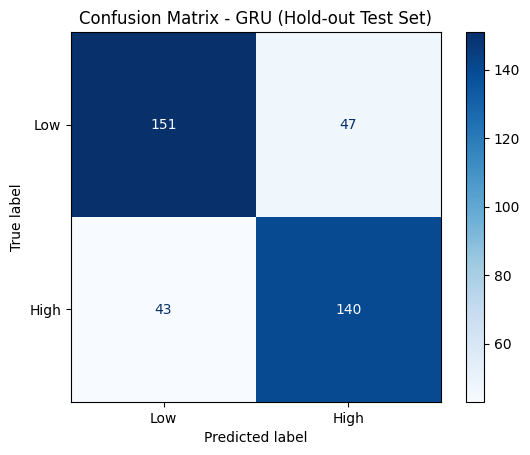

In [18]:
best_gru_hp = gru_tuner.get_best_hyperparameters()[0]

# Scale using train set statistics
scaler = StandardScaler()
X_train_final = scaler.fit_transform(
    X_train.reshape(-1, n_features)
).reshape(X_train.shape)
X_test_final = scaler.transform(
    X_test.reshape(-1, n_features)
).reshape(X_test.shape)

cw = dict(zip(*np.unique(y_train, return_counts=True)))
cw = {k: len(y_train) / (2 * v) for k, v in cw.items()}

tf.random.set_seed(42)
np.random.seed(42)

model = build_gru(best_gru_hp)
model.fit(
    X_train_final, y_train,
    epochs=50, batch_size=32,
    validation_split=0.2,
    class_weight=cw,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=0
)

y_pred = (model.predict(X_test_final, verbose=0) > 0.5).astype(int).flatten()

print("=== Test Set Results (GRU) ===")
print(classification_report(y_test, y_pred, target_names=['Low', 'High']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Low', 'High'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - GRU (Hold-out Test Set)')
plt.savefig('gru_confusion_matrix.pdf')
plt.show()